In [1]:
import os
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import json

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

from dataset.pairs.bin_reader import FacePairBinReader
from dataset.pairs.bin_visualizer import FacePairVisualizer
from utils.config_loader import Config
from utils.paths import ProjectPathResolver
from utils import analytics_tools as at

In [2]:
config_fpe = Config(path="config.fc_pair_eval.yaml")
path_resolver_fpe = ProjectPathResolver(config_fpe)

output_dir = path_resolver_fpe["paths.results_dir"]
os.makedirs(output_dir, exist_ok=True)
AGG_PLOTS_DIR = path_resolver_fpe["paths.all_aggregations_plot_dir"]
AGGREGATION_DIR = path_resolver_fpe["paths.all_aggregations_dir"]

In [3]:
reader = FacePairBinReader(path_resolver_fpe['paths.bin_subset'].path)
pairs = reader.load_pil_pairs()

In [4]:
output_dir = Path("/path/to/your/consolidated/output/directory/face_verification")
df_baseline_all_models_fcw112 = pd.read_csv(output_dir / "pair-gt_labat-cropped_image-warpe-112x112-len1180" / "pairs_predictions_all_models.csv")
df_baseline_all_models_ffidr = pd.read_csv(output_dir / "pair-gt_labat-full_image-default_480x640-len1180" / "pairs_predictions_all_models.csv")

In [5]:
position = df_baseline_all_models_fcw112.columns.get_loc('pair_id') + 1
df_baseline_all_models_fcw112.insert(loc=position, column='pair_set', value="FCW112")
df_baseline_all_models_ffidr.insert(loc=position, column='pair_set', value="FFIDR")
print(f"Length of FCW112 Full Committee {len(df_baseline_all_models_fcw112)}")
print(f"Length of FFIDR Full Committee {len(df_baseline_all_models_ffidr)}")

Length of FCW112 Full Committee 1180
Length of FFIDR Full Committee 1180


In [6]:
df_all_committee = pd.concat([df_baseline_all_models_fcw112, df_baseline_all_models_ffidr], ignore_index=True)
print(f"Length of All Full Committee Aggregation {len(df_all_committee)}")

Length of All Full Committee Aggregation 2360


In [7]:
df_all_committee

,pair_id,pair_set,ground_truth_is_same,score_similaridade_ViT-face,pred_fraude_ViT-face,score_similaridade_arcface-buffalo_l,pred_fraude_arcface-buffalo_l,score_similaridade_adaface,pred_fraude_adaface
0,0,FCW112,True,0.539921,True,0.422707,False,0.486679,False
1,1,FCW112,True,0.663795,False,0.656062,False,0.724300,False
2,2,FCW112,True,0.625526,False,0.102958,True,0.372621,False
3,3,FCW112,True,0.665465,False,0.613319,False,0.723384,False
4,4,FCW112,True,0.389802,True,0.015641,True,0.142696,True
...,...,...,...,...,...,...,...,...,...
2355,1175,FFIDR,False,0.458036,True,0.114065,True,0.069297,True
2356,1176,FFIDR,False,0.470497,True,0.010559,True,-0.040406,True
2357,1177,FFIDR,False,0.517700,True,0.105901,True,0.083696,True
2358,1178,FFIDR,False,0.537010,True,-0.098524,True,-0.008152,True


In [8]:
# --- 3. LÓGICA DO COMITÊ (ENSEMBLE) ---
# Soma dos votos de fraude (0 = Todos dizem genuíno, 3 = Todos dizem fraude)
df_all_committee['ground_truth_fraude'] = ~df_all_committee['ground_truth_is_same']
df_all_committee['soma_votos_fraude'] = df_all_committee[['pred_fraude_ViT-face', 'pred_fraude_arcface-buffalo_l', 'pred_fraude_adaface']].sum(axis=1)

# Voto da Maioria (Maior ou igual a 2 significa que a maioria achou que é fraude)
df_all_committee['pred_maioria'] = df_all_committee['soma_votos_fraude'] >= 2

# Nível de Concordância
df_all_committee['unanimidade'] = (df_all_committee['soma_votos_fraude'] == 0) | (df_all_committee['soma_votos_fraude'] == 3)
df_all_committee['divergencia'] = ~df_all_committee['unanimidade']

In [9]:
df_all_committee['ViT-face_acertou'] = df_all_committee['pred_fraude_ViT-face'] == df_all_committee['ground_truth_fraude']
df_all_committee['arcface-buffalo_l_acertou'] = df_all_committee['pred_fraude_arcface-buffalo_l'] == df_all_committee['ground_truth_fraude']
df_all_committee['adaface_acertou'] = df_all_committee['pred_fraude_adaface'] == df_all_committee['ground_truth_fraude']
df_all_committee['comite_acertou'] = df_all_committee['pred_maioria'] == df_all_committee['ground_truth_fraude']

In [10]:
# Garantir que temos o dataframe agregado com os dois pair_sets
assert "pair_set" in df_all_committee.columns, "df_all_committee precisa ter a coluna 'pair_set'."

def acc_pr_rec_f1_auc(y_pred_bool, y_true, score_continuo=None):
    """Helper: retorna (acc, f1, auc) dado y_pred binário e score opcional."""
    y_pred = y_pred_bool.astype(int)
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # AUC só faz sentido se tiver as duas classes presentes
    auc = None
    if score_continuo is not None:
        try:
            auc = roc_auc_score(y_true, score_continuo.astype(float))
        except ValueError:
            auc = None
    return acc, precision, recall, f1, auc

def compute_summary_for_df(df: pd.DataFrame, label: str) -> dict:
    """Calcula métricas de acurácia e concordância para um subconjunto do comitê."""
    total_pares = len(df)

    # Baselines (scores de fraude = 1 - score_similaridade_modelo)
    (acc_vit_face, pr_vit_face, rec_vit_face, f1_vit_face, auc_vit_face) = acc_pr_rec_f1_auc(
        df['pred_fraude_ViT-face'], df['ground_truth_fraude'],
        score_continuo=1.0 - df['score_similaridade_ViT-face']
    )
    acc_arcface, pr_arcface, rec_arcface, f1_arcface, auc_arcface = acc_pr_rec_f1_auc(
        df['pred_fraude_arcface-buffalo_l'], df['ground_truth_fraude'],
        score_continuo=1.0 - df['score_similaridade_arcface-buffalo_l']
    )
    acc_adaface, pr_adaface, rec_adaface, f1_adaface, auc_adaface = acc_pr_rec_f1_auc(
        df['pred_fraude_adaface'], df['ground_truth_fraude'],
        score_continuo=1.0 - df['score_similaridade_adaface']
    )

    # Comitê: score contínuo = proporção de votos de fraude (entre 0 e 1)
    n_modelos_votando = 6  # 3 LLMs + 3 baselines
    score_comite = df['soma_votos_fraude'] / n_modelos_votando

    (acc_comite, pr_comite, rec_comite, f1_comite, auc_comite) = acc_pr_rec_f1_auc(
        df['pred_maioria'], df['ground_truth_fraude'],
        score_continuo=score_comite
    )

    # Flags auxiliares
    unanimidade = df['unanimidade'].astype(bool)
    divergencia = df['divergencia'].astype(bool)
    comite_acertou = df['comite_acertou'].astype(bool)

    # Contagens básicas
    unanimes = int(unanimidade.sum())
    divergentes = int(divergencia.sum())

    # Unânimes corretos / errados
    unanimous_correct = int((unanimidade & comite_acertou).sum())
    unanimous_wrong = int((unanimidade & ~comite_acertou).sum())

    # Divergentes corretos / errados
    divergent_correct = int((divergencia & comite_acertou).sum())
    divergent_wrong = int((divergencia & ~comite_acertou).sum())

    return {
        "pair_set": label,
        "n_pares": total_pares,

        # Acurácia por modelo
        "acc_vit_face": acc_vit_face,
        "acc_arcface": acc_arcface,
        "acc_adaface": acc_adaface,
        "acc_comite": acc_comite,

        # --- F1 ---
        "f1_vit_face": f1_vit_face,
        "f1_arcface": f1_arcface,
        "f1_adaface": f1_adaface,
        "f1_comite": f1_comite,

        # --- Precision ---
        "pr_vit_face": pr_vit_face,
        "pr_arcface": pr_arcface,
        "pr_adaface": pr_adaface,
        "pr_comite": pr_comite,

        # --- Recall ---
        "rec_vit_face": rec_vit_face,
        "rec_arcface": rec_arcface,
        "rec_adaface": rec_adaface,
        "rec_comite": rec_comite,

        # --- AUC (podem ser None se só tiver uma classe no subset) ---
        "auc_vit_face": auc_vit_face,
        "auc_arcface": auc_arcface,
        "auc_adaface": auc_adaface,
        "auc_comite": auc_comite,

        # Proporções
        "pct_unanimidade": unanimes / total_pares if total_pares > 0 else np.nan,
        "pct_divergencia": divergentes / total_pares if total_pares > 0 else np.nan,

        # Contagens absolutas
        "unanimous_count": unanimes,
        "divergent_count": divergentes,
        "unanimous_correct": unanimous_correct,
        "unanimous_wrong": unanimous_wrong,
        "divergent_correct": divergent_correct,
        "divergent_wrong": divergent_wrong,

        # Compatibilidade com o nome antigo
        "alucinacao_coletiva": unanimous_wrong,
    }

# Lista de resumos: um por pair_set + um geral
resumos = []

for pair_set, df_sub in df_all_committee.groupby("pair_set"):
    resumos.append(compute_summary_for_df(df_sub, pair_set))

# Linha agregada (todos os pares)
resumos.append(compute_summary_for_df(df_all_committee, "ALL"))

summary_table = pd.DataFrame(resumos).set_index("pair_set")

# Se quiser ver porcentagens já formatadas como string para o notebook / artigo:
summary_table_fmt = summary_table.copy()
for col in ["acc_vit_face", "acc_arcface", "acc_adaface", "acc_comite", "pct_unanimidade", "pct_divergencia"]:
    summary_table_fmt[col] = (summary_table_fmt[col] * 100).map(lambda v: f"{v:.2f}%" if pd.notnull(v) else "NaN")

summary_table_fmt

,n_pares,acc_vit_face,acc_arcface,acc_adaface,acc_comite,f1_vit_face,f1_arcface,f1_adaface,f1_comite,pr_vit_face,...,auc_comite,pct_unanimidade,pct_divergencia,unanimous_count,divergent_count,unanimous_correct,unanimous_wrong,divergent_correct,divergent_wrong,alucinacao_coletiva
pair_set,,,,,,,,,,,,,,,,,,,,,
FCW112,1180,76.69%,88.98%,86.69%,88.22%,0.816789,0.908836,0.890896,0.904072,0.754926,...,0.916855,73.14%,26.86%,863,317,810,53,231,86,53
FFIDR,1180,75.25%,91.86%,92.03%,91.95%,0.811613,0.934605,0.935792,0.935242,0.730546,...,0.939392,75.68%,24.32%,893,287,843,50,242,45,50
ALL,2360,75.97%,90.42%,89.36%,90.08%,0.814159,0.921907,0.913538,0.919753,0.742379,...,0.928035,74.41%,25.59%,1756,604,1653,103,473,131,103


In [11]:
summary_json_path = AGGREGATION_DIR / "summary_fvb_committee.json"

# Estrutura: {pair_set: {..metrics..}}
summary_table.to_json(summary_json_path, orient="index", indent=2)
print(f"Resumo salvo em JSON: {summary_json_path}")

Resumo salvo em JSON: /mnt/ssd1/iarley/development/fraud_detection/results/flc_fv_aggregation/summary_fvb_committee.json


In [12]:
cols_comite = [c for c in summary_table_fmt.columns if c.endswith("comite")]
summary_table_comite = summary_table[cols_comite]
summary_table_comite

,acc_comite,f1_comite,pr_comite,rec_comite,auc_comite
pair_set,,,,,
FCW112,0.882203,0.904072,0.861842,0.950653,0.916855
FFIDR,0.919492,0.935242,0.881748,0.995646,0.939392
ALL,0.900847,0.919753,0.871912,0.973149,0.928035


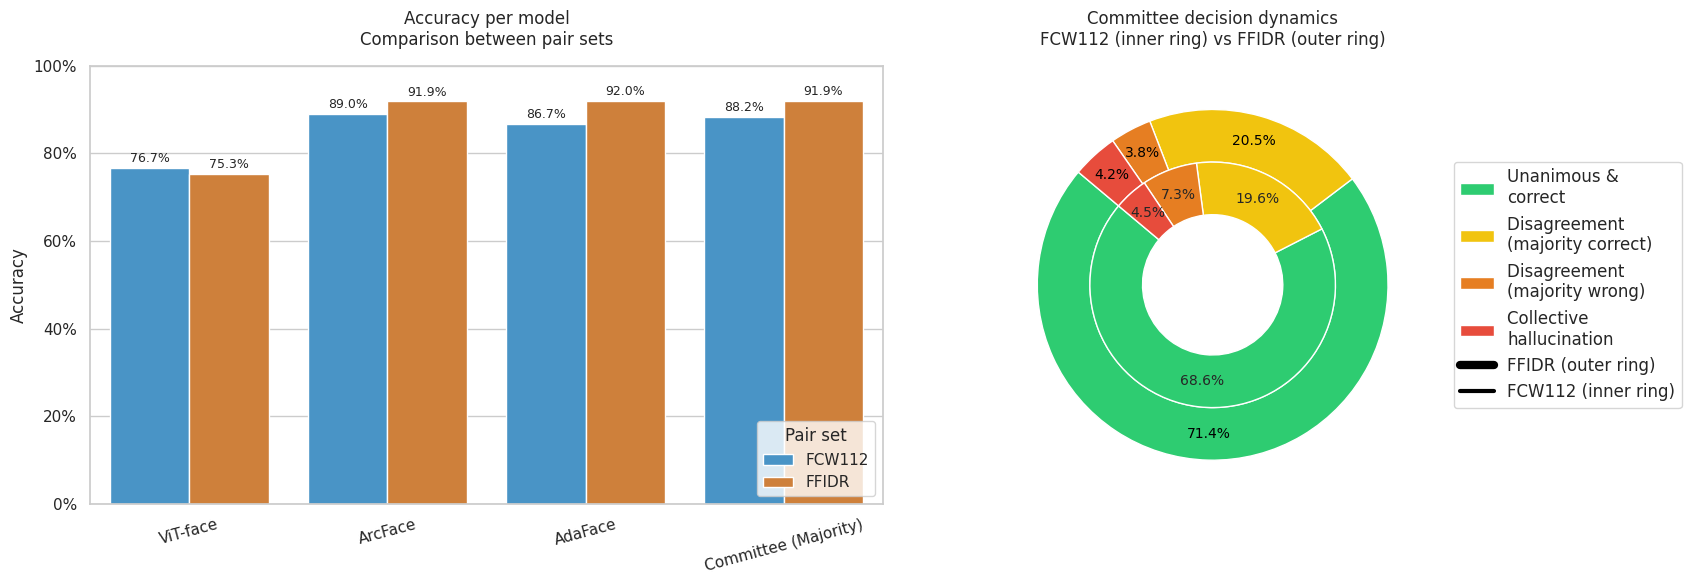

In [13]:
# --- GRÁFICOS PARA O ARTIGO (VERSÃO PARA PAPER) ---

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ============================================================
# 1) BAR CHART: ACCURACY PER MODEL (FCW112 vs FFIDR)
# ============================================================

# Extract accuracies by model for each pair set
acc_data = summary_table.loc[["FCW112", "FFIDR"], ["acc_vit_face", "acc_arcface", "acc_adaface", "acc_comite"]]
acc_data = acc_data.reset_index().rename(columns={"pair_set": "pair_set"})

# Long format for seaborn
acc_long = acc_data.melt(
    id_vars="pair_set",
    value_vars=["acc_vit_face", "acc_arcface", "acc_adaface", "acc_comite"],
    var_name="model",
    value_name="accuracy"
)

# Pretty labels for models
model_labels = {
    "acc_vit_face": "ViT-face",
    "acc_arcface": "ArcFace",
    "acc_adaface": "AdaFace",
    "acc_comite": "Committee (Majority)",
}
acc_long["model"] = acc_long["model"].map(model_labels)

ax_bar = axes[0]
sns.barplot(
    data=acc_long,
    x="model",
    y="accuracy",
    hue="pair_set",
    palette=["#3498db", "#e67e22"],
    ax=ax_bar
)

ax_bar.set_title("Accuracy per model\nComparison between pair sets", fontsize=12, pad=15)
ax_bar.set_xlabel("")
ax_bar.set_ylabel("Accuracy")
ax_bar.set_ylim(0, 1.0)
ax_bar.tick_params(axis='x', rotation=15)

# Y-axis in percentage
ax_bar.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.0%}"))

# Percentage labels on top of bars
for container in ax_bar.containers:
    ax_bar.bar_label(container, fmt=lambda v: f"{v:.1%}", padding=2, fontsize=9)

ax_bar.legend(title="Pair set", loc="lower right")

# ============================================================
# 2) DOUBLE DONUT PIE CHART: COMMITTEE DECISION DYNAMICS
#    Inner ring = FCW112, Outer ring = FFIDR
# ============================================================

def compute_pizza_sizes(df):
    """Return the 4 counts for the committee decision dynamics pie chart."""
    unanimous_correct = len(df[(df["unanimidade"] == True) & (df["comite_acertou"] == True)])
    divergent_majority_correct = len(df[(df["divergencia"] == True) & (df["comite_acertou"] == True)])
    divergent_majority_wrong = len(df[(df["divergencia"] == True) & (df["comite_acertou"] == False)])
    unanimous_wrong = len(df[(df["unanimidade"] == True) & (df["comite_acertou"] == False)])
    return [unanimous_correct, divergent_majority_correct, divergent_majority_wrong, unanimous_wrong]

sizes_fcw112 = compute_pizza_sizes(df_all_committee[df_all_committee['pair_set'] == 'FCW112'])
sizes_ffidr = compute_pizza_sizes(df_all_committee[df_all_committee['pair_set'] ==  'FFIDR'])

labels_en = [
    "Unanimous &\ncorrect",
    "Disagreement \n(majority correct)",
    "Disagreement \n(majority wrong)",
    "Collective \nhallucination",
]
colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]

ax_pie = axes[1]

total_fcw112 = sum(sizes_fcw112)
total_ffidr = sum(sizes_ffidr)

def autopct_inside(pct):
    return f"{pct:.1f}%"

# Outer ring: FFIDR (percent text inside outer annulus)
wedges_outer, texts_outer, autotexts_outer = ax_pie.pie(
    sizes_ffidr,
    radius=1.0,
    labels=None,
    colors=colors,
    startangle=140,
    autopct=autopct_inside,
    pctdistance=0.85,
    wedgeprops=dict(width=0.3, edgecolor="white"),
    textprops=dict(color="black", fontsize=10),
)

# Inner ring: FCW112 (we will place text manually inside each wedge)
wedges_inner, texts_inner = ax_pie.pie(
    sizes_fcw112,
    radius=0.7,
    labels=None,
    colors=colors,
    startangle=140,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Place, for each inner wedge, a "label\nXX.X%" text inside the colored region
for wedge, value in zip(wedges_inner, sizes_fcw112):
    ang = (wedge.theta2 + wedge.theta1) / 2.0
    ang_rad = np.deg2rad(ang)

    # middle radius of the inner ring (0.7 outer, width=0.3 → inner radius 0.4, middle ~0.55)
    r = 0.55

    x = r * np.cos(ang_rad)
    y = r * np.sin(ang_rad)

    pct = 100.0 * value / total_fcw112 if total_fcw112 > 0 else 0.0

    ax_pie.text(
        x,
        y,
        f"{pct:.1f}%",
        ha="center",
        va="center",
        fontsize=10,
    )

ax_pie.set(aspect="equal")
ax_pie.set_title("Committee decision dynamics\nFCW112 (inner ring) vs FFIDR (outer ring)", fontsize=12, pad=15,)

# Legend: colors → categories, lines → which ring is which dataset
handles_cat = [Patch(facecolor=c, edgecolor="white", label=lab) for c, lab in zip(colors, labels_en)]
handles_ring = [
    Line2D([0], [0], color="black", lw=6, label="FFIDR (outer ring)"),
    Line2D([0], [0], color="black", lw=3, label="FCW112 (inner ring)"),
]

ax_pie.legend(
    handles_cat + handles_ring,
    [h.get_label() for h in handles_cat + handles_ring],
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    borderaxespad=0.0,
    fontsize=12,
)

at.save_plot(fig, AGG_PLOTS_DIR, "fvb_committee_accuracy_and_donut.png")

plt.tight_layout()
plt.show()

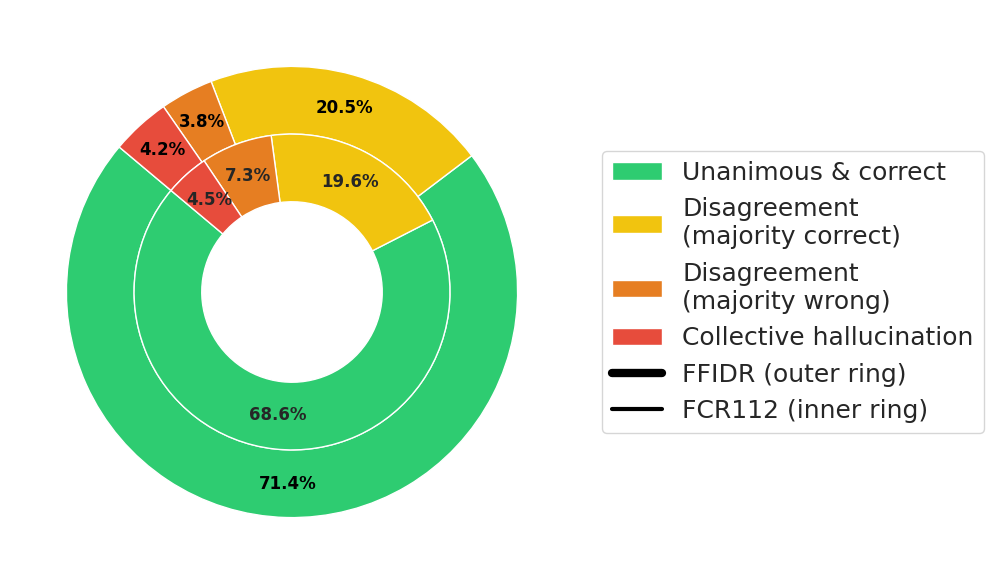

In [14]:
# ============================================================
# 2) DOUBLE DONUT PIE CHART: COMMITTEE DECISION DYNAMICS
#    Inner ring = FCW112, Outer ring = FFIDR
# ============================================================

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 1, figsize=(18, 6))

def compute_pizza_sizes(df):
    """Return the 4 counts for the committee decision dynamics pie chart."""
    unanimous_correct = len(df[(df["unanimidade"] == True) & (df["comite_acertou"] == True)])
    divergent_majority_correct = len(df[(df["divergencia"] == True) & (df["comite_acertou"] == True)])
    divergent_majority_wrong = len(df[(df["divergencia"] == True) & (df["comite_acertou"] == False)])
    unanimous_wrong = len(df[(df["unanimidade"] == True) & (df["comite_acertou"] == False)])
    return [unanimous_correct, divergent_majority_correct, divergent_majority_wrong, unanimous_wrong]

sizes_fcw112 = compute_pizza_sizes(df_all_committee[df_all_committee['pair_set'] == 'FCW112'])
sizes_ffidr = compute_pizza_sizes(df_all_committee[df_all_committee['pair_set'] ==  'FFIDR'])

labels_en = [
    "Unanimous & correct",
    "Disagreement\n(majority correct)",
    "Disagreement\n(majority wrong)",
    "Collective hallucination",
]
colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]

ax_pie = axes

total_fcw112 = sum(sizes_fcw112)
total_ffidr = sum(sizes_ffidr)

def autopct_inside(pct):
    return f"{pct:.1f}%"

# Outer ring: FFIDR (percent text inside outer annulus)
wedges_outer, texts_outer, autotexts_outer = ax_pie.pie(
    sizes_ffidr,
    radius=1.0,
    labels=None,
    colors=colors,
    startangle=140,
    autopct=autopct_inside,
    pctdistance=0.85,
    wedgeprops=dict(width=0.3, edgecolor="white"),
    textprops=dict(color="black", fontsize=12, fontweight="bold",),
)

# Inner ring: FCW112 (we will place text manually inside each wedge)
wedges_inner, texts_inner = ax_pie.pie(
    sizes_fcw112,
    radius=0.7,
    labels=None,
    colors=colors,
    startangle=140,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Place, for each inner wedge, a "label\nXX.X%" text inside the colored region
for wedge, value in zip(wedges_inner, sizes_fcw112):
    ang = (wedge.theta2 + wedge.theta1) / 2.0
    ang_rad = np.deg2rad(ang)

    # middle radius of the inner ring (0.7 outer, width=0.3 → inner radius 0.4, middle ~0.55)
    r = 0.55

    x = r * np.cos(ang_rad)
    y = r * np.sin(ang_rad)

    pct = 100.0 * value / total_fcw112 if total_fcw112 > 0 else 0.0

    ax_pie.text(
        x,
        y,
        f"{pct:.1f}%",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
    )

ax_pie.set(aspect="equal")
# ax_pie.set_title(
#     "Committee decision dynamics\nFCW112 (inner ring) vs FFIDR (outer ring)",
#     fontsize=12,
#     pad=15,
# )

# Legend: colors → categories, lines → which ring is which dataset
handles_cat = [Patch(facecolor=c, edgecolor="white", label=lab) for c, lab in zip(colors, labels_en)]
handles_ring = [
    Line2D([0], [0], color="black", lw=6, label="FFIDR (outer ring)"),
    Line2D([0], [0], color="black", lw=3, label="FCR112 (inner ring)"),
]

ax_pie.legend(
    handles_cat + handles_ring,
    [h.get_label() for h in handles_cat + handles_ring],
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    borderaxespad=0.0,
    fontsize=18,
)

at.save_plot(fig, AGG_PLOTS_DIR, "fvb_committee_double_donut_labeled.png")

plt.tight_layout()
plt.show()